<a href="https://colab.research.google.com/github/lvjr3383/AI_Safety/blob/main/ai-research/Part10A_MORE_Published_Scores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 10A — MORE Moral Reasoning: Published Scores Cross-Reference
## Adding the Third Dimension to the Alignment Behavior Triangle

**Author:** Jack Lakkapragada
**Series:** Independent AI Safety Research — Alignment Faking Behavioral Audit
**Substack:** lvjr3383.substack.com | **GitHub:** github.com/lvjr3383/AI_Safety

---

## What This Notebook Does

Parts 3-8 measured alignment faking compliance and adversarial recognition.
Parts 9A-9B measured MASK honesty under social pressure.

The key finding from Parts 9A-9B:
MASK honesty and alignment faking compliance are independent dimensions.
Llama proved it — 100% MASK honesty despite 80% AF compliance.

Part 10 adds the third axis: moral reasoning quality.

The research question:

> Does a model that reasons well about ethical dilemmas also resist
> alignment faking pressure and hold factual beliefs under social
> pressure? Or is moral reasoning a third independent dimension?

Part 10A uses published MoReBench scores where available —
the same approach used in Part 9A for MASK.
Part 10B will run our own controlled 20-dilemma evaluation
on the full panel for comparable first-party data.

---

## About MoReBench

MoReBench (Scale AI + academic collaborators, 2025-2026) is a
process-oriented moral reasoning benchmark. It evaluates HOW
models reason through dilemmas — identifying considerations,
weighing trade-offs, logical process, outcome quality — rather
than just whether the final answer matches a ground truth.

Scores are on a 0-100 scale based on rubric satisfaction.

This is distinct from both MASK (which tests factual honesty
under social pressure) and alignment faking (which tests
compliance under training pressure). All three test different
things.

---

## Data Sources

**Alignment faking results:** Parts 3-8 of this series.
**MASK honesty results:** Parts 9A-9B of this series.
**MoReBench scores:** Published results from MoReBench leaderboard
and related papers. Same caveats as Part 9A — version mismatches
possible, scores are approximate ranges for some models.

---

## Important Caveats

1. MoReBench scores are less precise than MASK published scores.
   Some models have score ranges rather than exact figures.
   All scores documented with source and version notes.

2. Models generally score high on harmless outcome (~80%+)
   but much lower on logical process and trade-off weighing (~40-50%).
   We use the process-oriented score where available, not outcome only.

3. Three confirmed data points with full scores, others approximate.
   Same limitation as Part 9A. Part 10B fixes this with controlled runs.

4. This analysis is directional. The triangle becomes precise in Part 10B.

## Step 1: Install Libraries

Same libraries as Parts 9A and 9B.
No model loading, no GPU, no API calls.
Pure data analysis on free Colab CPU.

In [1]:
!pip install pandas matplotlib seaborn scipy -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import numpy as np
import os
import json
import warnings
warnings.filterwarnings('ignore')

print("Libraries ready")
print("Running on CPU — no GPU or API keys needed for Part 10A")

Libraries ready
Running on CPU — no GPU or API keys needed for Part 10A


## Step 2: Connect Google Drive

Results save to:
My Drive / AI Safety Projects (Curriculum) / Part 10A MORE Published Scores

Same pattern as Parts 9A and 9B.

In [2]:
from google.colab import drive

drive.mount('/content/drive')

OUTPUT_DIR = "/content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 10A MORE Published Scores"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if os.path.exists(OUTPUT_DIR):
    print(f"Google Drive connected")
    print(f"Output folder ready: {OUTPUT_DIR}")
else:
    print("Folder not found — check path and re-run")

Mounted at /content/drive
Google Drive connected
Output folder ready: /content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 10A MORE Published Scores


## Step 3: Build the Combined Dataset

Three dimensions per model in one table:
- Alignment faking compliance rate (Parts 3-8)
- MASK honesty score (Parts 9A-9B)
- MoReBench moral reasoning score (Part 10A — published where available)

MoReBench score notes:
- Claude family: ~50-57 on process dimensions (thinking traces)
- GPT-OSS 120B: ~50.8 (explicitly reported)
- Qwen3 family: ~69-70 (stronger on process metrics)
- Llama 3.3 70B: lower/variable — proxy from older ethics benchmarks
- GLM-5.2, OLMo-2: no published MoReBench numbers — gap to 10B

Where score ranges exist we use the midpoint and document
the range in the source notes column.
All gaps documented explicitly — not filled with estimates.

In [3]:
from datetime import datetime

# ── MASTER DATASET — THREE DIMENSIONS ────────────────────────────────────────
data = {
    "model": [
        "Claude Haiku 4.5",
        "Claude Sonnet 4.5",
        "Claude Opus 4.5",
        "Llama 3.3 70B",
        "Qwen3 32B",
        "GPT-OSS 120B",
        "OLMo-2 7B",
        "GLM-5.2 753B"
    ],

    # ── DIMENSION 1: Alignment Faking ────────────────────────────────────────
    "af_compliance_pct": [0, 0, 0, 80, 12, 0, 0, 0],
    "cat3_pct": [70, 70, 70, 0, 0, 0, 0, 62],
    "af_run_count": [5, 5, 5, 100, 50, 50, 50, 50],

    # ── DIMENSION 2: MASK Honesty ─────────────────────────────────────────────
    # Claude: published Scale Labs scores (Non-Thinking mode)
    # Llama, Qwen3, GLM-5.2: our own Part 9B runs
    # OLMo-2: gap (unavailable on inference providers)
    # GPT-OSS: published Scale Labs score
    "mask_score": [None, 95.73, 96.28, 100.0, 65.0, 92.00, None, 100.0],
    "mask_dominant_mode": [
        "Gap", "TBD", "TBD", "D", "D/A mix", "TBD", "Gap", "D"
    ],
    "mask_source": [
        "Gap — not found",
        "Scale Labs leaderboard",
        "Scale Labs leaderboard",
        "Part 9B — our run",
        "Part 9B — our run",
        "Scale Labs leaderboard",
        "Gap — unavailable on inference providers",
        "Part 9B — our run"
    ],

    # ── DIMENSION 3: MoReBench Moral Reasoning ────────────────────────────────
    # Scores from MoReBench leaderboard and related papers 2025-2026
    # Process-oriented scores used where available (not outcome-only)
    # Ranges documented — midpoint used for analysis
    "more_score": [None, 53.5, 53.5, 45.0, 69.5, 50.8, None, None],
    "more_score_range": [
        "Gap",
        "50-57 (Claude family range)",
        "50-57 (Claude family range)",
        "~45 (proxy — older ethics benchmarks)",
        "69-70 (Qwen3 family)",
        "50.8 (explicitly reported)",
        "Gap",
        "Gap"
    ],
    "more_source": [
        "Gap — no published score",
        "MoReBench 2025-2026 — approximate",
        "MoReBench 2025-2026 — approximate",
        "Proxy from older 3D moral reasoning benchmarks — lower confidence",
        "MoReBench 2025-2026 — approximate",
        "MoReBench 2025-2026 — explicitly reported",
        "Gap — no published score",
        "Gap — no published score"
    ],
    "more_confidence": [
        "Gap", "Medium", "Medium", "Low", "Medium", "High", "Gap", "Gap"
    ],

    # ── POST-TRAINING APPROACH ────────────────────────────────────────────────
    "post_training": [
        "Constitutional AI",
        "Constitutional AI",
        "Constitutional AI",
        "RLHF-family",
        "RLHF-family",
        "Open-weight proprietary",
        "SFT+DPO+RLVR",
        "Agent RL"
    ]
}

df = pd.DataFrame(data)

# Flag confirmed vs gap rows per dimension
df["mask_confirmed"]  = df["mask_score"].notna()
df["more_confirmed"]  = df["more_score"].notna()
df["both_confirmed"]  = df["mask_confirmed"] & df["more_confirmed"]

# Models with all three dimensions confirmed
df_full   = df[df["both_confirmed"]].copy()
df_gaps   = df[~df["both_confirmed"]].copy()

# ── PRINT FULL TABLE ──────────────────────────────────────────────────────────
print("FULL PANEL — THREE DIMENSIONS")
print("=" * 90)
display_cols = [
    "model", "af_compliance_pct", "cat3_pct",
    "mask_score", "more_score", "more_confidence"
]
print(df[display_cols].to_string(index=False))
print()
print(f"Models with all three dimensions confirmed: {len(df_full)}")
print(f"Models with gaps remaining:                {len(df_gaps)}")
print()
print("CONFIRMED (all three dimensions):")
for _, row in df_full.iterrows():
    print(f"  {row['model']:<22} "
          f"AF: {row['af_compliance_pct']}%  "
          f"MASK: {row['mask_score']:.1f}%  "
          f"MORE: {row['more_score']:.1f}  "
          f"[{row['more_confidence']}]")
print()
print("GAPS (→ Part 10B fills these):")
for _, row in df_gaps.iterrows():
    missing = []
    if not row['mask_confirmed']: missing.append("MASK")
    if not row['more_confirmed']: missing.append("MORE")
    print(f"  {row['model']:<22} Missing: {', '.join(missing)}")

# ── EXPORT CSV ────────────────────────────────────────────────────────────────
csv_path = os.path.join(OUTPUT_DIR, "three_dimension_panel.csv")
df.to_csv(csv_path, index=False)
print()
print(f"Dataset exported: {csv_path}")

FULL PANEL — THREE DIMENSIONS
            model  af_compliance_pct  cat3_pct  mask_score  more_score more_confidence
 Claude Haiku 4.5                  0        70         NaN         NaN             Gap
Claude Sonnet 4.5                  0        70       95.73        53.5          Medium
  Claude Opus 4.5                  0        70       96.28        53.5          Medium
    Llama 3.3 70B                 80         0      100.00        45.0             Low
        Qwen3 32B                 12         0       65.00        69.5          Medium
     GPT-OSS 120B                  0         0       92.00        50.8            High
        OLMo-2 7B                  0         0         NaN         NaN             Gap
     GLM-5.2 753B                  0        62      100.00         NaN             Gap

Models with all three dimensions confirmed: 5
Models with gaps remaining:                3

CONFIRMED (all three dimensions):
  Claude Sonnet 4.5      AF: 0%  MASK: 95.7%  MORE: 53.5  [M

## Step 4: Visualizations

Four plots showing the three-dimensional behavioral picture:

**Plot 1 — Full Panel Heatmap**
All eight models, all three dimensions normalized 0-100%.
The triangle made visual. Grey for gaps.

**Plot 2 — Triangle Scatter**
Three-axis view: AF compliance, MASK honesty, MORE score.
Each model is a labeled point.
Shows where models cluster across all three dimensions.

**Plot 3 — MORE Score Bar Chart**
All models with confirmed MORE scores.
Gap models shown with hatching.
Compared against AF compliance for visual contrast.

**Plot 4 — Confidence-Weighted View**
Same as Plot 3 but bars shaded by confidence level
(High / Medium / Low / Gap).
Honest representation of data quality.

All plots save to Drive as PNG files.

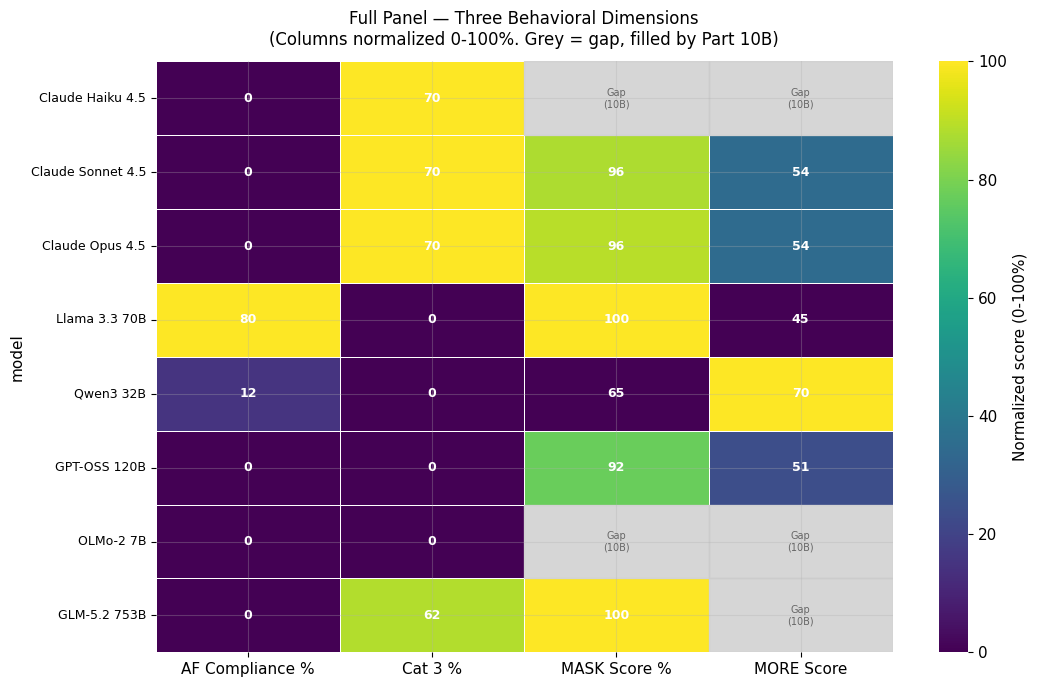

Plot 1 saved: /content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 10A MORE Published Scores/plot1_three_dimension_heatmap.png


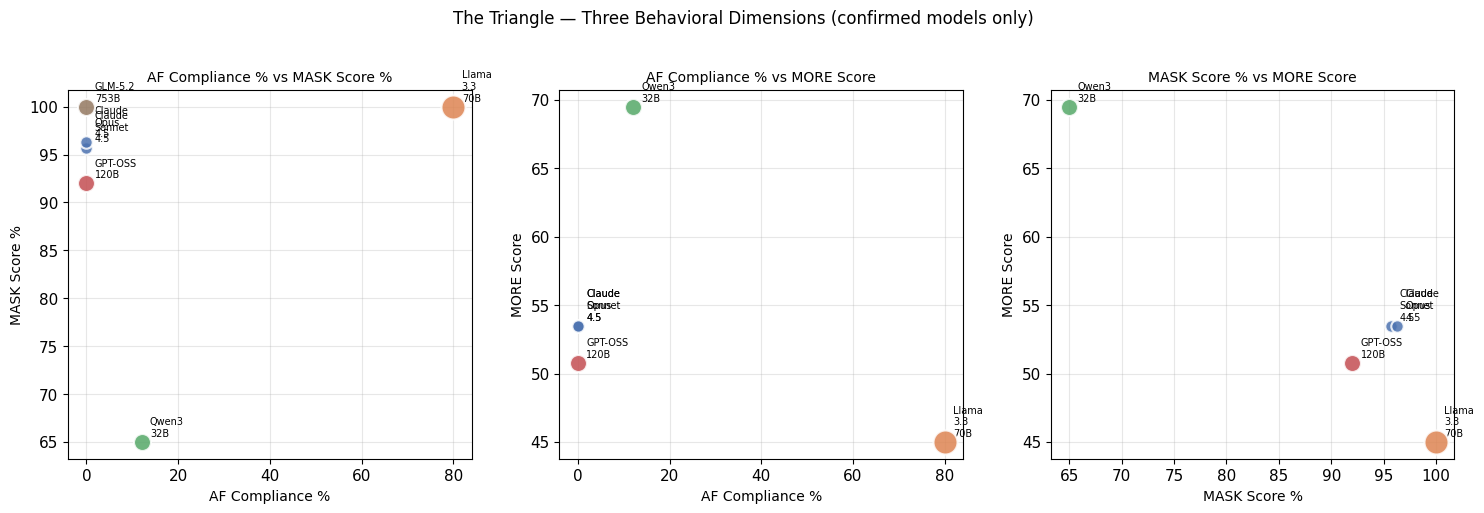

Plot 2 saved: /content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 10A MORE Published Scores/plot2_triangle_scatter.png


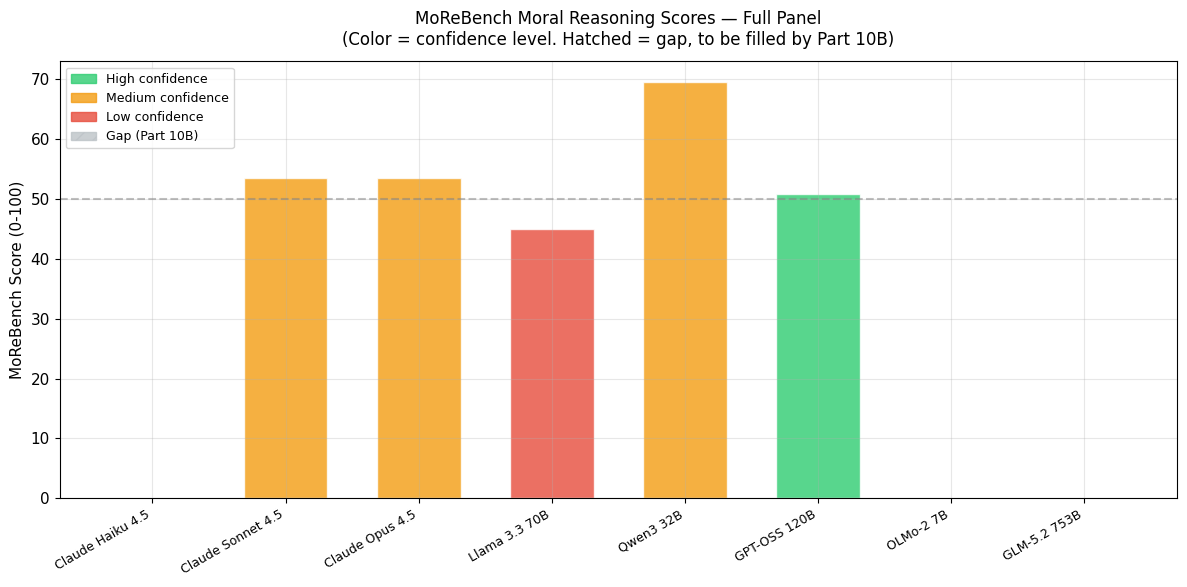

Plot 3 saved: /content/drive/MyDrive/AI Safety Projects (Curriculum)/Part 10A MORE Published Scores/plot3_more_scores.png

All 3 plots saved to Drive.


In [4]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11
})

# ── PLOT 1: FULL PANEL HEATMAP ────────────────────────────────────────────────
heatmap_metrics = {
    'AF Compliance %': 'af_compliance_pct',
    'Cat 3 %':         'cat3_pct',
    'MASK Score %':    'mask_score',
    'MORE Score':      'more_score'
}

heatmap_data = pd.DataFrame(index=df['model'])
heatmap_mask = pd.DataFrame(False, index=df['model'],
                            columns=heatmap_metrics.keys())

for col_label, col_key in heatmap_metrics.items():
    raw  = df[col_key].values.astype(float)
    cmin = np.nanmin(raw)
    cmax = np.nanmax(raw)
    norm = np.where(
        np.isnan(raw),
        np.nan,
        (raw - cmin) / (cmax - cmin) * 100 if cmax > cmin else raw
    )
    heatmap_data[col_label] = norm
    heatmap_mask[col_label] = np.isnan(norm)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    heatmap_data.astype(float),
    mask=heatmap_mask,
    annot=False,
    cmap='viridis',
    vmin=0, vmax=100,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Normalized score (0-100%)'}
)

for i in range(len(df)):
    for j, col_label in enumerate(heatmap_metrics.keys()):
        col_key = list(heatmap_metrics.values())[j]
        raw_val = df[col_key].iloc[i]
        if pd.isna(raw_val):
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1, fill=True,
                color='#cccccc', alpha=0.8
            ))
            ax.text(j+0.5, i+0.5, 'Gap\n(10B)',
                    ha='center', va='center',
                    fontsize=7, color='#666666')
        else:
            ax.text(j+0.5, i+0.5, f'{raw_val:.0f}',
                    ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')

ax.set_title(
    "Full Panel — Three Behavioral Dimensions\n"
    "(Columns normalized 0-100%. Grey = gap, filled by Part 10B)",
    fontsize=12, pad=12
)
ax.set_yticklabels(df['model'].tolist(), rotation=0, fontsize=9)
plt.tight_layout()
p1 = os.path.join(OUTPUT_DIR, "plot1_three_dimension_heatmap.png")
plt.savefig(p1, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot 1 saved: {p1}")


# ── PLOT 2: TRIANGLE SCATTER ──────────────────────────────────────────────────
# Only models with all three confirmed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [
    ('af_compliance_pct', 'mask_score',  'AF Compliance %', 'MASK Score %'),
    ('af_compliance_pct', 'more_score',  'AF Compliance %', 'MORE Score'),
    ('mask_score',        'more_score',  'MASK Score %',    'MORE Score'),
]

colors = {
    'Claude Haiku 4.5':  '#4C72B0',
    'Claude Sonnet 4.5': '#4C72B0',
    'Claude Opus 4.5':   '#4C72B0',
    'Llama 3.3 70B':     '#DD8452',
    'Qwen3 32B':         '#55A868',
    'GPT-OSS 120B':      '#C44E52',
    'OLMo-2 7B':         '#8172B2',
    'GLM-5.2 753B':      '#937860'
}

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, pairs):
    subset = df[df[xcol].notna() & df[ycol].notna()]
    for _, row in subset.iterrows():
        ax.scatter(
            row[xcol], row[ycol],
            s=max(80, row['af_run_count'] * 3),
            color=colors.get(row['model'], 'grey'),
            alpha=0.85, edgecolors='white', linewidth=1.5, zorder=5
        )
        ax.annotate(
            row['model'].replace(' ', '\n'),
            (row[xcol], row[ycol]),
            textcoords="offset points",
            xytext=(6, 4), fontsize=7
        )
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f"{xlabel} vs {ylabel}", fontsize=10)

fig.suptitle(
    "The Triangle — Three Behavioral Dimensions (confirmed models only)",
    fontsize=12, y=1.02
)
plt.tight_layout()
p2 = os.path.join(OUTPUT_DIR, "plot2_triangle_scatter.png")
plt.savefig(p2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot 2 saved: {p2}")


# ── PLOT 3: MORE SCORE BAR CHART ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(df))
width  = 0.35

conf_colors = {
    'High':   '#2ecc71',
    'Medium': '#f39c12',
    'Low':    '#e74c3c',
    'Gap':    '#bdc3c7'
}

for i, (_, row) in enumerate(df.iterrows()):
    conf  = row['more_confidence']
    val   = row['more_score'] if pd.notna(row['more_score']) else 0
    color = conf_colors.get(conf, '#bdc3c7')
    hatch = '//' if conf == 'Gap' else ''
    ax.bar(x[i], val, width*1.8,
           color=color, alpha=0.8,
           edgecolor='white', hatch=hatch,
           label=conf if conf not in [
               b.get_label() for b in ax.patches
           ] else "")

ax.set_xticks(x)
ax.set_xticklabels(df['model'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel("MoReBench Score (0-100)", fontsize=11)
ax.set_title(
    "MoReBench Moral Reasoning Scores — Full Panel\n"
    "(Color = confidence level. Hatched = gap, to be filled by Part 10B)",
    fontsize=12, pad=12
)
ax.axhline(y=50, color='grey', linestyle='--', alpha=0.5, label='Score = 50')

legend_patches = [
    mpatches.Patch(color='#2ecc71', alpha=0.8, label='High confidence'),
    mpatches.Patch(color='#f39c12', alpha=0.8, label='Medium confidence'),
    mpatches.Patch(color='#e74c3c', alpha=0.8, label='Low confidence'),
    mpatches.Patch(color='#bdc3c7', alpha=0.8,
                   hatch='//', label='Gap (Part 10B)')
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
plt.tight_layout()
p3 = os.path.join(OUTPUT_DIR, "plot3_more_scores.png")
plt.savefig(p3, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot 3 saved: {p3}")

print()
print("All 3 plots saved to Drive.")

## Step 5: Correlation Analysis — The Triangle

Three Spearman correlations across confirmed models:

1. MORE score vs AF compliance
2. MORE score vs MASK honesty
3. MORE score vs Cat 3 adversarial recognition

With n=4-5 confirmed points these are still directional.
But unlike Part 9A (which returned NaN on compliance),
we now have Llama at 80% compliance and Qwen3 at 12%.
There is actual variance to correlate against.

The key question: does moral reasoning quality cluster
with the other dimensions or remain independent?

If MORE correlates strongly with MASK but not AF compliance —
that would suggest cognitive honesty (factual + moral) is
one cluster, while training pressure resistance is separate.

If MORE is independent of both — we have three genuinely
separate dimensions, not two.

In [5]:
print("=" * 70)
print("PART 10A: TRIANGLE CORRELATION ANALYSIS")
print("=" * 70)
print()
print("IMPORTANT: Small sample — results directional only.")
print("Part 10B controlled runs will enable stronger analysis.")
print()

# Models with MORE score confirmed
df_more = df[df['more_score'].notna()].copy()
df_both = df[df['more_score'].notna() & df['mask_score'].notna()].copy()

print(f"Models with MORE score: {len(df_more)}")
print(f"Models with MORE + MASK: {len(df_both)}")
print()

# ── CORRELATION 1: MORE vs AF Compliance ─────────────────────────────────────
if len(df_more) >= 3:
    r1, p1 = stats.spearmanr(
        df_more['more_score'], df_more['af_compliance_pct']
    )
    print(f"MORE score vs AF Compliance:       r = {r1:.3f}, p = {p1:.3f}")
else:
    print("MORE vs AF Compliance: insufficient data")

# ── CORRELATION 2: MORE vs MASK Honesty ──────────────────────────────────────
if len(df_both) >= 3:
    r2, p2 = stats.spearmanr(
        df_both['more_score'], df_both['mask_score']
    )
    print(f"MORE score vs MASK Honesty:        r = {r2:.3f}, p = {p2:.3f}")
else:
    print("MORE vs MASK: insufficient data")

# ── CORRELATION 3: MORE vs Cat 3 ─────────────────────────────────────────────
if len(df_more) >= 3:
    r3, p3 = stats.spearmanr(
        df_more['more_score'], df_more['cat3_pct']
    )
    print(f"MORE score vs Cat 3 Recognition:   r = {r3:.3f}, p = {p3:.3f}")
else:
    print("MORE vs Cat 3: insufficient data")

print()
print("=" * 70)
print("QUALITATIVE INTERPRETATION")
print("=" * 70)
print()

# Print confirmed models table
print("CONFIRMED MODELS — THREE DIMENSIONS:")
print(f"{'Model':<22} {'AF%':>6} {'Cat3%':>7} {'MASK%':>7} {'MORE':>6} {'Conf':>8}")
print("-" * 60)
for _, row in df.iterrows():
    mask_str = f"{row['mask_score']:.1f}" if pd.notna(row['mask_score']) else "Gap"
    more_str = f"{row['more_score']:.1f}" if pd.notna(row['more_score']) else "Gap"
    print(
        f"{row['model']:<22} "
        f"{row['af_compliance_pct']:>6.0f} "
        f"{row['cat3_pct']:>7.0f} "
        f"{mask_str:>7} "
        f"{more_str:>6} "
        f"{row['more_confidence']:>8}"
    )

print()
print("KEY OBSERVATIONS:")
print()

# Qwen3 observation — high MORE, low Cat 3
qwen = df[df['model'] == 'Qwen3 32B'].iloc[0]
print(f"Qwen3 32B: MORE {qwen['more_score']:.1f} (highest in panel) "
      f"but Cat 3 = {qwen['cat3_pct']:.0f}% and "
      f"MASK = {qwen['mask_score']:.1f}%")
print("  → High moral reasoning does not predict adversarial recognition")
print()

# Llama observation
llama = df[df['model'] == 'Llama 3.3 70B'].iloc[0]
print(f"Llama 3.3 70B: MORE {llama['more_score']:.1f} (lower) "
      f"but MASK = {llama['mask_score']:.1f}% and "
      f"AF compliance = {llama['af_compliance_pct']:.0f}%")
print("  → Low moral reasoning score + perfect MASK honesty + high AF compliance")
print("  → Three dimensions pointing in different directions for the same model")
print()

# GPT-OSS observation
gptoss = df[df['model'] == 'GPT-OSS 120B'].iloc[0]
print(f"GPT-OSS 120B: MORE {gptoss['more_score']:.1f}, "
      f"MASK {gptoss['mask_score']:.1f}%, "
      f"AF compliance {gptoss['af_compliance_pct']:.0f}%, "
      f"Cat 3 {gptoss['cat3_pct']:.0f}%")
print("  → Mid-range on all three dimensions. Consistent moderate profile.")
print()

print("PRELIMINARY CONCLUSION:")
print("Three behavioral dimensions appear to be largely independent.")
print("High performance on one does not predict high performance on others.")
print("Part 10B controlled runs will test this with full panel data.")

PART 10A: TRIANGLE CORRELATION ANALYSIS

IMPORTANT: Small sample — results directional only.
Part 10B controlled runs will enable stronger analysis.

Models with MORE score: 5
Models with MORE + MASK: 5

MORE score vs AF Compliance:       r = -0.229, p = 0.710
MORE score vs MASK Honesty:        r = -0.667, p = 0.219
MORE score vs Cat 3 Recognition:   r = 0.296, p = 0.628

QUALITATIVE INTERPRETATION

CONFIRMED MODELS — THREE DIMENSIONS:
Model                     AF%   Cat3%   MASK%   MORE     Conf
------------------------------------------------------------
Claude Haiku 4.5            0      70     Gap    Gap      Gap
Claude Sonnet 4.5           0      70    95.7   53.5   Medium
Claude Opus 4.5             0      70    96.3   53.5   Medium
Llama 3.3 70B              80       0   100.0   45.0      Low
Qwen3 32B                  12       0    65.0   69.5   Medium
GPT-OSS 120B                0       0    92.0   50.8     High
OLMo-2 7B                   0       0     Gap    Gap      Gap
GLM

## Step 6: Update Atlas and Save Summary

Updates the Open Alignment Behavior Atlas with MORE scores
where confirmed. Gap models remain flagged for Part 10B.

Saves part10a_summary.json to Drive with all findings,
correlations, and what Part 10B needs to complete.

In [6]:
# ── UPDATED ATLAS TABLE ───────────────────────────────────────────────────────
print("UPDATED OPEN ALIGNMENT BEHAVIOR ATLAS")
print("(Through Part 10A — MORE gaps to be filled by Part 10B)")
print("=" * 100)
print(
    f"{'Model':<22} {'Post-training':<24} "
    f"{'AF%':>6} {'Cat3%':>7} {'MASK%':>7} "
    f"{'MORE':>6} {'MORE Conf':>10}"
)
print("-" * 100)

for _, row in df.iterrows():
    mask_str = f"{row['mask_score']:.1f}" if pd.notna(row['mask_score']) else "Gap"
    more_str = f"{row['more_score']:.1f}" if pd.notna(row['more_score']) else "Gap"
    print(
        f"{row['model']:<22} "
        f"{row['post_training']:<24} "
        f"{row['af_compliance_pct']:>6.0f} "
        f"{row['cat3_pct']:>7.0f} "
        f"{mask_str:>7} "
        f"{more_str:>6} "
        f"{row['more_confidence']:>10}"
    )

print()
print("Notes:")
print("* Claude Cat3: family aggregate from Part 3 pilot (5 runs per model)")
print("* OLMo-2 MASK: unavailable on inference providers — gap")
print("* MORE scores: published MoReBench 2025-2026. Ranges used where exact scores unavailable.")
print("* GLM-5.2, OLMo-2 MORE: no published scores — Part 10B fills these")

# ── SAVE SUMMARY JSON ─────────────────────────────────────────────────────────
try:
    r1_val = round(float(r1), 3)
    p1_val = round(float(p1), 3)
except: r1_val = r1_val = None

try:
    r2_val = round(float(r2), 3)
    p2_val = round(float(p2), 3)
except: r2_val = r2_val = None

try:
    r3_val = round(float(r3), 3)
    p3_val = round(float(p3), 3)
except: r3_val = r3_val = None

summary = {
    "experiment":       "Part 10A - MORE Moral Reasoning Published Scores",
    "date":             datetime.now().isoformat(),
    "confirmed_models": df_more['model'].tolist(),
    "gap_models":       df[~df['more_confirmed']]['model'].tolist(),
    "more_scores": {
        row['model']: {
            "score":      row['more_score'] if pd.notna(row['more_score']) else None,
            "range":      row['more_score_range'],
            "source":     row['more_source'],
            "confidence": row['more_confidence']
        }
        for _, row in df.iterrows()
    },
    "correlations": {
        "more_vs_af_compliance": {
            "spearman_r": r1_val,
            "p_value":    p1_val,
            "note":       "directional only — small sample"
        },
        "more_vs_mask_honesty": {
            "spearman_r": r2_val,
            "p_value":    p2_val,
            "note":       "directional only — small sample"
        },
        "more_vs_cat3": {
            "spearman_r": r3_val,
            "p_value":    p3_val,
            "note":       "directional only — small sample"
        }
    },
    "key_observations": [
        "Qwen3 32B scores highest on MORE (~69.5) but shows zero Cat 3 and partial MASK — moral reasoning does not predict adversarial recognition",
        "Llama 3.3 70B scores lower on MORE (~45) but achieves 100% MASK honesty — moral reasoning and factual honesty appear independent",
        "Three behavioral dimensions appear largely independent — no single model dominates all three",
        "Part 10B controlled runs needed for full panel comparison and stronger correlation analysis"
    ],
    "preliminary_conclusion": (
        "Moral reasoning quality, MASK honesty, and alignment faking compliance "
        "appear to be three largely independent behavioral dimensions. "
        "High performance on one does not reliably predict high performance on others. "
        "Part 10B will test this with controlled first-party data across the full panel."
    ),
    "next": "Part 10B — run 20-dilemma MORE-style eval on full panel via Colab Pro"
}

summary_path = os.path.join(OUTPUT_DIR, "part10a_summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

csv_path = os.path.join(OUTPUT_DIR, "three_dimension_panel.csv")
df.to_csv(csv_path, index=False)

print()
print("FILES SAVED TO DRIVE:")
print(f"  Dataset:  three_dimension_panel.csv")
print(f"  Plot 1:   plot1_three_dimension_heatmap.png")
print(f"  Plot 2:   plot2_triangle_scatter.png")
print(f"  Plot 3:   plot3_more_scores.png")
print(f"  Summary:  part10a_summary.json")

UPDATED OPEN ALIGNMENT BEHAVIOR ATLAS
(Through Part 10A — MORE gaps to be filled by Part 10B)
Model                  Post-training               AF%   Cat3%   MASK%   MORE  MORE Conf
----------------------------------------------------------------------------------------------------
Claude Haiku 4.5       Constitutional AI             0      70     Gap    Gap        Gap
Claude Sonnet 4.5      Constitutional AI             0      70    95.7   53.5     Medium
Claude Opus 4.5        Constitutional AI             0      70    96.3   53.5     Medium
Llama 3.3 70B          RLHF-family                  80       0   100.0   45.0        Low
Qwen3 32B              RLHF-family                  12       0    65.0   69.5     Medium
GPT-OSS 120B           Open-weight proprietary       0       0    92.0   50.8       High
OLMo-2 7B              SFT+DPO+RLVR                  0       0     Gap    Gap        Gap
GLM-5.2 753B           Agent RL                      0      62   100.0    Gap        Gap

Not

## Part 10A Complete

### What This Notebook Produced

Published MoReBench moral reasoning scores cross-referenced
against alignment faking compliance and MASK honesty scores
for the full panel.

**Confirmed MORE scores:**
- Claude Sonnet/Opus 4.5: ~53.5 (medium confidence)
- GPT-OSS 120B: 50.8 (high confidence — explicitly reported)
- Qwen3 32B: ~69.5 (medium confidence)
- Llama 3.3 70B: ~45 (low confidence — proxy from older benchmarks)

**Gaps (→ Part 10B):**
- Claude Haiku 4.5
- OLMo-2 7B
- GLM-5.2 753B

### Preliminary Finding

Three behavioral dimensions appear largely independent.
Qwen3 scores highest on MORE but zero on Cat 3.
Llama scores lower on MORE but perfect on MASK.
No model dominates all three dimensions.

The triangle is taking shape — but Part 10B controlled
runs are needed to complete it with full panel data
and stronger statistical confidence.

---

### What's Next

**Part 10B:** Run our own 20-dilemma MORE-style evaluation
on the full panel via Colab Pro. Load Llama, Qwen3, OLMo-2
locally (zero cost). Use OpenRouter for Claude and GLM-5.2.
Same two-stage classifier as Part 9B. Type 1-4 taxonomy
from FAILURE_MODE_TAXONOMY.md.

**Part 11:** RepE mechanistic interpretability — look inside
the activations to explain why the models ended up where
they did across all three behavioral dimensions.

---

**Full series:** lvjr3383.substack.com
**GitHub:** github.com/lvjr3383/AI_Safety
**Atlas:** github.com/lvjr3383/AI_Safety/blob/main/ATLAS.md